<a href="https://colab.research.google.com/github/fablasettik-cmd/data-science-Coder-/blob/main/C%C3%B3pia_de_ProyectoDSParteII%2BBlasettiKuhn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Global Data on Sustainable Energy (2000-2020)
Descargado de: https://www.kaggle.com/datasets/anshtanwar/global-data-on-sustainable-energy

About Dataset
Description
Uncover this dataset showcasing sustainable energy indicators and other useful factors across all countries from 2000 to 2020. Dive into vital aspects such as electricity access, renewable energy, carbon emissions, energy intensity, Financial flows, and economic growth. Compare nations, track progress towards Sustainable Development Goal 7, and gain profound insights into global energy consumption patterns over time.

Key Features:

Entity: The name of the country or region for which the data is reported.

Year: The year for which the data is reported, ranging from 2000 to 2020.

Access to electricity: The percentage of population with access to electricity.

Access to clean fuels for cooking: The percentage of the population with primary reliance on clean fuels.

Renewable-electricity-generating-capacity-per-capita: Installed Renewable energy capacity per person.

Financial flows to developing countries: Aid and assistance from developed countries for clean energy projects.

Renewable energy share in total final energy consumption: Percentage of renewable energy in final energy consumption.

Electricity from fossil fuels: Electricity generated from fossil fuels (coal, oil, gas) in terawatt-hours.

Electricity from nuclear: Electricity generated from nuclear power in terawatt-hours.

Electricity from renewables: Electricity generated from renewable sources in terawatt-hours.

Low-carbon electricity: Percentage of electricity from low-carbon sources.

Primary energy consumption per capita: Energy consumption per person in kilowatt-hours.

Energy intensity level of primary energy: Energy use per unit of GDP at purchasing power parity.

Value_co2_emissions: Carbon dioxide emissions per person in metric tons.

Renewables: Equivalent primary energy that is derived from renewable sources.

GDP growth: Annual GDP growth rate based on constant local currency.

GDP per capita: Gross domestic product per person.

Density: Population density in persons per square kilometer.

Land Area: Total land area in square kilometers.

Latitude: Latitude of the country's centroid in decimal degrees.

Longitude: Longitude of the country's centroid in decimal degrees.

Potential Use cases

Energy Consumption Prediction: Predict future energy usage, aid planning, and track SDG 7 progress.

Carbon Emission Forecasting: Forecast CO2 emissions, support climate strategies.

Energy Access Classification: Categorize regions for infrastructure development, understand sustainable energy's role.

Sustainable Development Goal Tracking: Monitor progress towards Goal 7, evaluate policy impact.

Energy Equity Analysis: Analyze access, density, and growth for equitable distribution.

Energy Efficiency Optimization: Identify intensive areas for environmental impact reduction.

Renewable Energy Potential Assessment: Identify regions for green investments based on capacity.

Renewable Energy Investment Strategies: Guide investors towards sustainable opportunities.

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

In [90]:
url = "https://raw.githubusercontent.com/fablasettik-cmd/data-science-Coder-/refs/heads/main/dataset%20-%20global-data-on-sustainable-energy.csv"
df = pd.read_csv (url)

In [91]:
df.shape

(3649, 21)

In [92]:
df.head()

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity from fossil fuels (TW

In [94]:
#Verificación de valores nulos
print("Valores nulos NAN")
df.isnull().sum()

Valores nulos NAN


,0
Entity,0
Year,0
Access to electricity (% of population),10
Access to clean fuels for cooking,169
Renewable-electricity-generating-capacity-per-capita,931
Financial flows to developing countries (US $),2089
Renewable energy share in the total final energy consumption (%),194
Electricity from fossil fuels (TWh),21
Electricity from nuclear (TWh),126
Electricity from renewables (TWh),21


In [95]:
#Convierto columna Entity en String
obj_column_to_string = ['Entity']
df [obj_column_to_string] = df [obj_column_to_string].astype("string")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   string 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity from fossil fuels (TW

In [96]:
#Al ser Entity el Target, me fijo si todas tienen la misma cantidad de filas
df["Entity"].value_counts()

,count
Entity,
Afghanistan,21
Albania,21
Algeria,21
Angola,21
Antigua and Barbuda,21
...,...
Uzbekistan,21
Serbia,14
Montenegro,14


In [97]:
#Elimino las 37 filas de Entity con los países que tienen menos de 21 entradas y conservo solo los que tienen las series completas.

df = df.groupby("Entity").filter(lambda x: len(x) == 21)
df["Entity"].value_counts()

,count
Entity,
Afghanistan,21
Albania,21
Algeria,21
Angola,21
Antigua and Barbuda,21
...,...
Uzbekistan,21
Vanuatu,21
Yemen,21


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3612 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3612 non-null   string 
 1   Year                                                              3612 non-null   int64  
 2   Access to electricity (% of population)                           3603 non-null   float64
 3   Access to clean fuels for cooking                                 3444 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2709 non-null   float64
 5   Financial flows to developing countries (US $)                    1554 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3421 non-null   float64
 7   Electricity from fossil fuels (TWh)   

In [99]:
#Por problemas en la interpretación del símbolo '\n', para poder cambiarla de object a número. Primero veo cómo queda registrado el nombre
print(df.columns.tolist())

['Entity', 'Year', 'Access to electricity (% of population)', 'Access to clean fuels for cooking', 'Renewable-electricity-generating-capacity-per-capita', 'Financial flows to developing countries (US $)', 'Renewable energy share in the total final energy consumption (%)', 'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', 'Electricity from renewables (TWh)', 'Low-carbon electricity (% electricity)', 'Primary energy consumption per capita (kWh/person)', 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)', 'Value_co2_emissions_kt_by_country', 'Renewables (% equivalent primary energy)', 'gdp_growth', 'gdp_per_capita', 'Density\\n(P/Km2)', 'Land Area(Km2)', 'Latitude', 'Longitude']


In [100]:
#Por problemas en la interpretación por parte de Python del símbol '\n', cambio el nombre de la columna Density\n(P/Km2)
df = df.rename(columns={
    'Density\\n(P/Km2)': 'Density Km2'
    })
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3612 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3612 non-null   string 
 1   Year                                                              3612 non-null   int64  
 2   Access to electricity (% of population)                           3603 non-null   float64
 3   Access to clean fuels for cooking                                 3444 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2709 non-null   float64
 5   Financial flows to developing countries (US $)                    1554 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3421 non-null   float64
 7   Electricity from fossil fuels (TWh)   

In [101]:
#Detecté una coma (,) que me impedía transformar esa columna a número, por lo cual elimino la coma y lo transformo en float64
df["Density Km2"] = df["Density Km2"].astype(str).str.replace(",", "").astype("float64")

In [102]:
#Porcentaje de valores no faltantes respecto al total de datos (3612)
porcentaje = (df.notnull().sum() / len(df) * 100).round(2)
print(porcentaje)

Entity                                                              100.00
Year                                                                100.00
Access to electricity (% of population)                              99.75
Access to clean fuels for cooking                                    95.35
Renewable-electricity-generating-capacity-per-capita                 75.00
Financial flows to developing countries (US $)                       43.02
Renewable energy share in the total final energy consumption (%)     94.71
Electricity from fossil fuels (TWh)                                  99.42
Electricity from nuclear (TWh)                                       96.51
Electricity from renewables (TWh)                                    99.42
Low-carbon electricity (% electricity)                               98.84
Primary energy consumption per capita (kWh/person)                  100.00
Energy intensity level of primary energy (MJ/$2017 PPP GDP)          94.49
Value_co2_emissions_kt_by

In [103]:
#Por la poca cantidad de columnas con el 100% de valores no faltantes, elimino las tres columnas que no llegan al 80% de los datos completos.

df = df.drop(columns=[
    'Renewable-electricity-generating-capacity-per-capita',
    'Financial flows to developing countries (US $)',
    'Renewables (% equivalent primary energy)'
])

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3612 entries, 0 to 3648
Data columns (total 18 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3612 non-null   string 
 1   Year                                                              3612 non-null   int64  
 2   Access to electricity (% of population)                           3603 non-null   float64
 3   Access to clean fuels for cooking                                 3444 non-null   float64
 4   Renewable energy share in the total final energy consumption (%)  3421 non-null   float64
 5   Electricity from fossil fuels (TWh)                               3591 non-null   float64
 6   Electricity from nuclear (TWh)                                    3486 non-null   float64
 7   Electricity from renewables (TWh)     

In [105]:
df.shape

(3612, 18)

In [106]:
#Relleno las columnas con NaN con los promedios de cada país (Entity) para cada columna, como imputación simple
reemplazo_NaN = [
    'Access to electricity (% of population)',
    'Access to clean fuels for cooking',
    'Renewable energy share in the total final energy consumption (%)',
    'Electricity from fossil fuels (TWh)',
    'Electricity from nuclear (TWh)',
    'Electricity from renewables (TWh)',
    'Low-carbon electricity (% electricity)',
    'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
    'Value_co2_emissions_kt_by_country',
    'gdp_growth',
    'gdp_per_capita'
]


df[reemplazo_NaN] = df.groupby('Entity', group_keys=False)[reemplazo_NaN].apply(
    lambda x: x.fillna(x.mean())
)

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3612 entries, 0 to 3648
Data columns (total 18 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3612 non-null   string 
 1   Year                                                              3612 non-null   int64  
 2   Access to electricity (% of population)                           3612 non-null   float64
 3   Access to clean fuels for cooking                                 3444 non-null   float64
 4   Renewable energy share in the total final energy consumption (%)  3591 non-null   float64
 5   Electricity from fossil fuels (TWh)                               3591 non-null   float64
 6   Electricity from nuclear (TWh)                                    3486 non-null   float64
 7   Electricity from renewables (TWh)     

In [108]:
#Veo cuántos nulos quedaron
print(df[reemplazo_NaN].isnull().sum())


Access to electricity (% of population)                               0
Access to clean fuels for cooking                                   168
Renewable energy share in the total final energy consumption (%)     21
Electricity from fossil fuels (TWh)                                  21
Electricity from nuclear (TWh)                                      126
Electricity from renewables (TWh)                                    21
Low-carbon electricity (% electricity)                               42
Energy intensity level of primary energy (MJ/$2017 PPP GDP)          21
Value_co2_emissions_kt_by_country                                   252
gdp_growth                                                          231
gdp_per_capita                                                      231
dtype: int64


In [109]:
#Para las columnas que siguen teniendo datos faltantes, reemplazo los NaN por los promedios generales de la columna

df['Access to clean fuels for cooking'] = df['Access to clean fuels for cooking'].fillna(
    df['Access to clean fuels for cooking'].mean())
df['Renewable energy share in the total final energy consumption (%)'] = df['Renewable energy share in the total final energy consumption (%)'].fillna(
    df['Renewable energy share in the total final energy consumption (%)'].mean())
df['Electricity from fossil fuels (TWh)'] = df['Electricity from fossil fuels (TWh)'].fillna(
    df['Electricity from fossil fuels (TWh)'].mean())

df['Electricity from nuclear (TWh)'] = df['Electricity from nuclear (TWh)'].fillna(
    df['Electricity from nuclear (TWh)'].mean())
df['Electricity from renewables (TWh)'] = df['Electricity from renewables (TWh)'].fillna(
    df['Electricity from renewables (TWh)'].mean())
df['Low-carbon electricity (% electricity)'] = df['Low-carbon electricity (% electricity)'].fillna(
    df['Low-carbon electricity (% electricity)'].mean())
df['Energy intensity level of primary energy (MJ/$2017 PPP GDP)'] = df['Energy intensity level of primary energy (MJ/$2017 PPP GDP)'].fillna(
    df['Energy intensity level of primary energy (MJ/$2017 PPP GDP)'].mean())
df['Value_co2_emissions_kt_by_country'] = df['Value_co2_emissions_kt_by_country'].fillna(
    df['Value_co2_emissions_kt_by_country'].mean())
df['gdp_growth'] = df['gdp_growth'].fillna(
    df['gdp_growth'].mean())
df['gdp_per_capita'] = df['gdp_per_capita'].fillna(
    df['gdp_per_capita'].mean())

df.isnull().sum()



,0
Entity,0
Year,0
Access to electricity (% of population),0
Access to clean fuels for cooking,0
Renewable energy share in the total final energy consumption (%),0
Electricity from fossil fuels (TWh),0
Electricity from nuclear (TWh),0
Electricity from renewables (TWh),0
Low-carbon electricity (% electricity),0
Primary energy consumption per capita (kWh/person),0


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3612 entries, 0 to 3648
Data columns (total 18 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3612 non-null   string 
 1   Year                                                              3612 non-null   int64  
 2   Access to electricity (% of population)                           3612 non-null   float64
 3   Access to clean fuels for cooking                                 3612 non-null   float64
 4   Renewable energy share in the total final energy consumption (%)  3612 non-null   float64
 5   Electricity from fossil fuels (TWh)                               3612 non-null   float64
 6   Electricity from nuclear (TWh)                                    3612 non-null   float64
 7   Electricity from renewables (TWh)     

In [111]:
df.describe()

,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_growth,gdp_per_capita,Density Km2,Land Area(Km2),Latitude,Longitude
count,3612.000000,3612.000000,3612.000000,3612.00000,3612.000000,3612.000000,3612.000000,3612.000000,3612.000000,3612.000000,3.612000e+03,3612.000000,3612.000000,3612.000000,3.612000e+03,3612.000000,3612.000000
mean,2010.000000,78.770521,63.372038,32.64319,70.978961,13.592949,24.168307,36.850451,25818.892355,5.309257,1.607182e+05,3.473975,13367.955244,225.191860,6.377437e+05,18.076870,14.744577
std,6.056139,30.312678,38.202630,29.91376,348.767096,72.088324,104.642509,34.211989,34929.100376,3.516046,7.473156e+05,5.453514,19245.621284,686.660723,1.592554e+06,24.171832,66.671784
min,2000.000000,1.252269,0.100000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.110000,1.000000e+01,-62.075920,111.927225,2.000000,2.100000e+01,-40.900557,-175.198242
25%,2005.000000,58.717497,25.712500,6.48000,0.290000,0.000000,0.050000,3.022727,3116.018450,3.170000,2.290000e+03,1.578507,1412.810611,33.250000,2.618175e+04,2.861308,-12.448007
50%,2010.000000,98.173258,79.800000,23.58000,3.010000,0.000000,1.480000,28.581767,13004.358500,4.320000,1.495000e+04,3.473975,5147.392153,88.000000,1.180420e+05,17.125346,18.938671
75%,2015.000000,100.000000,100.000000,55.27250,27.775000,0.000000,10.020000,64.286180,34091.760500,6.008000,9.385250e+04,5.706638,14349.912550,220.000000,5.168320e+05,38.965238,46.366989
max,2020.000000,100.000000,100.000000,96.04000,5184.130000,809.410000,2184.940000,100.000010,262585.700000,32.570000,1.070722e+07,123.139555,123514.196700,8358.000000,9.984670e+06,64.963051,178.065032


**HIPÓTESIS 0: Los indicadores económicos y de acceso a la energía permiten predecir el consumo energético per cápita a futuro.**

**HIPÓTESIS 1: El PBI (GDP) per cápita no determina el consumo energético.**

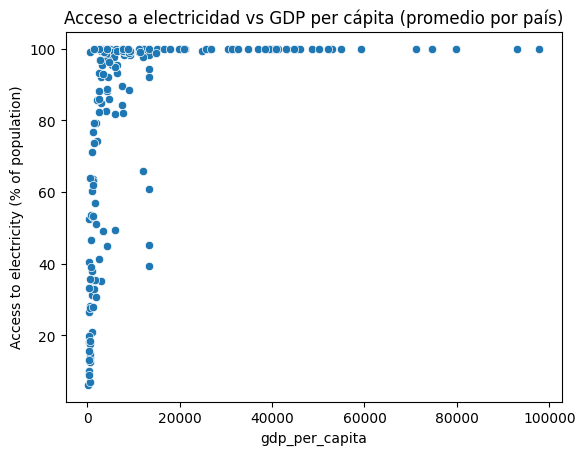

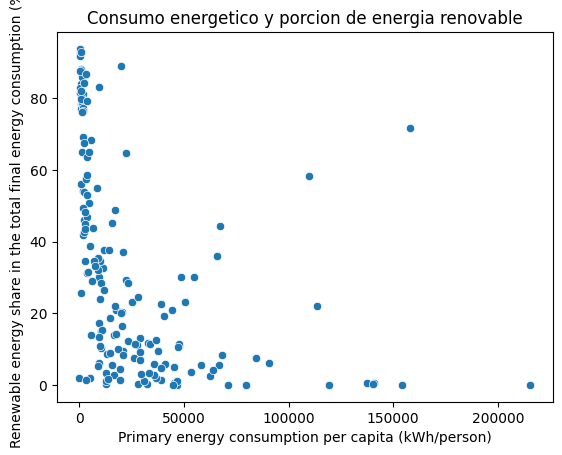

In [112]:
# Promedios por país
df_prom = df.groupby('Entity')[['Access to electricity (% of population)',
                                 'Primary energy consumption per capita (kWh/person)',
                                 'gdp_per_capita', 'Renewable energy share in the total final energy consumption (%)']].mean().reset_index()

sns.scatterplot(data=df_prom,
                x='gdp_per_capita',
                y='Access to electricity (% of population)')
plt.title('Acceso a electricidad vs GDP per cápita (promedio por país)')
plt.show()


sns.scatterplot(data=df_prom,
                x='Primary energy consumption per capita (kWh/person)',
                y='Renewable energy share in the total final energy consumption (%)')
plt.title('Consumo energetico y porcion de energia renovable')
plt.show()

In [113]:
#Agrupamos clusters por similitud aplicando Kmeans, de forma no supervisada

features = [
    'gdp_per_capita',
    'Access to electricity (% of population)',
    'Primary energy consumption per capita (kWh/person)',
    'Renewable energy share in the total final energy consumption (%)'
]

X = df_prom[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=4, random_state=42)
df_prom['cluster'] = kmeans.fit_predict(X_scaled)

<Axes: xlabel='gdp_per_capita', ylabel='Primary energy consumption per capita (kWh/person)'>

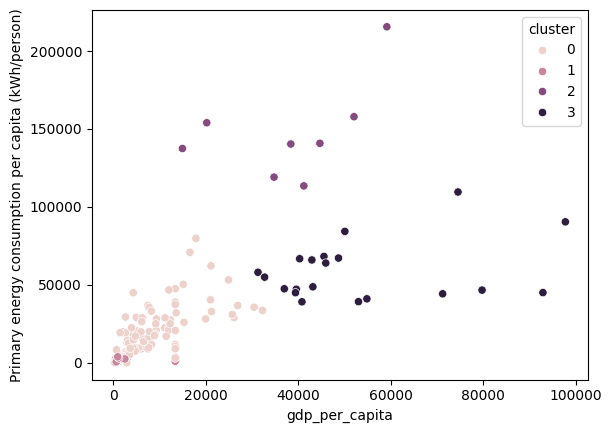

In [114]:
#Graficamos los clusters
sns.scatterplot(
    data=df_prom,
    x='gdp_per_capita',
    y='Primary energy consumption per capita (kWh/person)',
    hue='cluster'
)



<Axes: xlabel='gdp_per_capita', ylabel='Access to electricity (% of population)'>

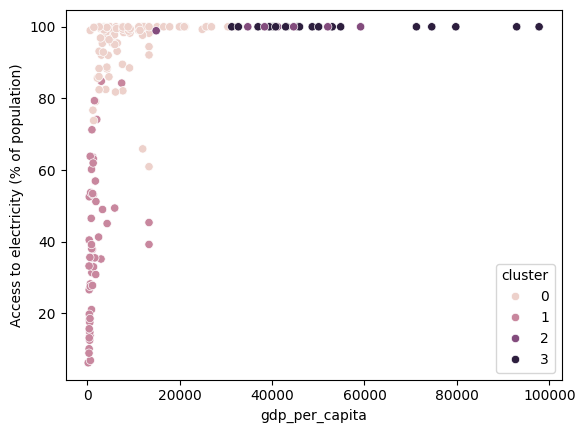

In [115]:
sns.scatterplot(
    data=df_prom,
    x='gdp_per_capita',
    y='Access to electricity (% of population)',
    hue='cluster'
)

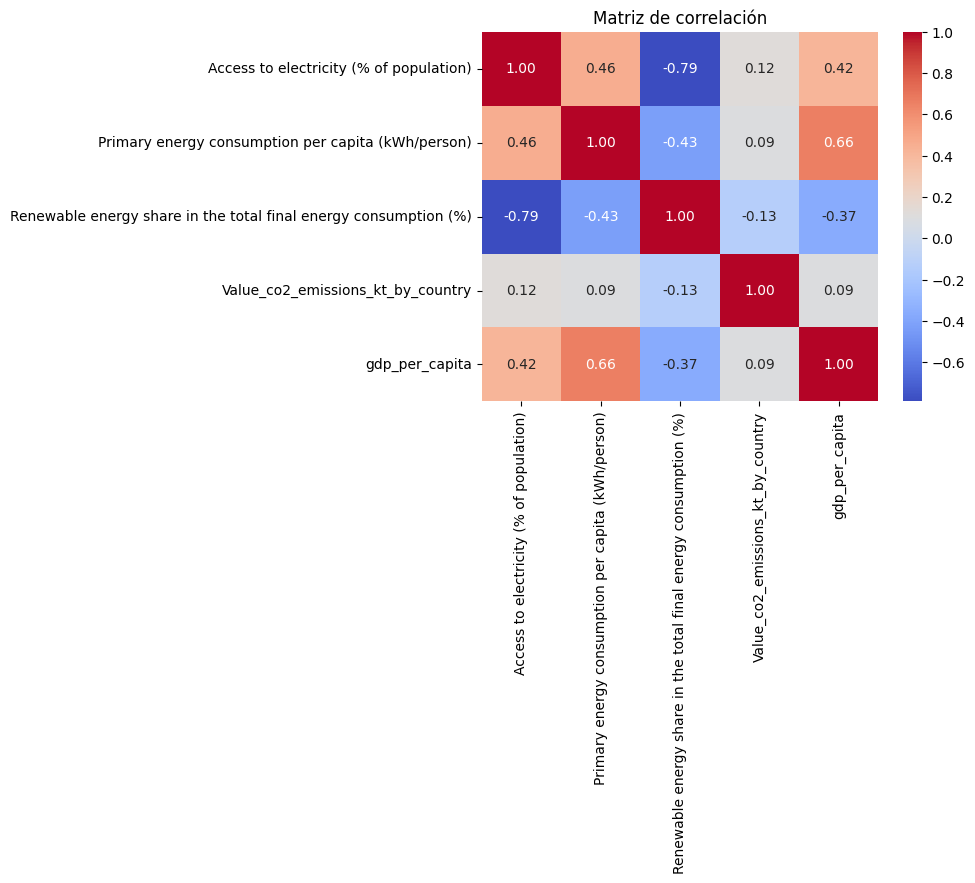

In [116]:
#Se elabora un gráfico para ver las correlaciones entre las columnas que más nos permiten acercarnos a las hipótesis
cols_correlacion = [
    'Access to electricity (% of population)',
    'Primary energy consumption per capita (kWh/person)',
    'Renewable energy share in the total final energy consumption (%)',
    'Value_co2_emissions_kt_by_country',
    'gdp_per_capita'
]

corr = df[cols_correlacion].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

CONCLUSIONES PRELIMINARES:


*   Los países con mayor acceso a electricidad tienen menor proporción de energías renovables
*   A mayor riqueza, mayor consumo energético per cápita
*   El acceso a la electricidad no deriva necesariamente en más energías renovables
*  Países que consumen más tienden a depender menos de renovables

In [117]:
#Variables que definen consumo energético y pbi
feat_cluster = [
    "Access to electricity (% of population)",
    "Primary energy consumption per capita (kWh/person)",
    "Renewable energy share in the total final energy consumption (%)",
    "Value_co2_emissions_kt_by_country",
    "gdp_per_capita",
]

country = df.groupby("Entity", as_index=False)[feat_cluster].mean()

Xc = country[feat_cluster].values
Xc_scaled = StandardScaler().fit_transform(Xc)

#Por sugerencia de LLM, usamos pocos k (3, 4, 5) y aplicamos silhouette
for k in range(3, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(Xc_scaled)
    sil = silhouette_score(Xc_scaled, labels)
    print(f"k={k}  silhouette={sil:.3f}")

k_final = 4  # elegí según la tabla anterior
km = KMeans(n_clusters=k_final, random_state=42, n_init="auto")
country["cluster"] = km.fit_predict(Xc_scaled)
country.sort_values("cluster")

k=3  silhouette=0.473
k=4  silhouette=0.471
k=5  silhouette=0.499


,Entity,Access to electricity (% of population),Primary energy consumption per capita (kWh/person),Renewable energy share in the total final energy consumption (%),Value_co2_emissions_kt_by_country,gdp_per_capita,cluster
1,Albania,99.981429,11353.520929,32.64319,4.303000e+03,3623.224775,0
2,Algeria,99.108146,12925.532952,0.28700,1.199210e+05,3787.817377,0
5,Argentina,98.241525,20954.674810,9.56050,1.604620e+05,9238.734894,0
4,Antigua and Barbuda,98.823761,32065.486190,0.20050,5.130000e+02,13555.401528,0
6,Armenia,99.498020,13100.438333,8.55300,4.776500e+03,2886.863105,0
...,...,...,...,...,...,...,...
128,Qatar,100.000000,215565.206190,0.07200,6.000900e+04,59167.671117,3
156,Trinidad and Tobago,98.896223,137467.305952,0.48950,1.828050e+04,14916.511495,3
140,Singapore,100.000000,140814.132381,0.56850,4.237300e+04,44673.397566,3
165,United States,100.000000,84297.163429,7.51400,5.329539e+06,50076.813150,3


In [118]:

target = "Primary energy consumption per capita (kWh/person)"
X = df.drop(columns=["Entity", target], errors="ignore").select_dtypes(include=[np.number])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

k = min(8, X_train.shape[1])
selector = SelectKBest(score_func=f_regression, k=k)
X_tr = selector.fit_transform(X_train, y_train)
X_te = selector.transform(X_test)

reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
reg.fit(X_tr, y_train)
y_pred = reg.predict(X_te)

print("Features seleccionadas:", X_train.columns[selector.get_support()].tolist())
print("R²:", r2_score(y_test, y_pred))

Features seleccionadas: ['Access to electricity (% of population)', 'Access to clean fuels for cooking', 'Renewable energy share in the total final energy consumption (%)', 'Electricity from nuclear (TWh)', 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)', 'gdp_per_capita', 'Density Km2', 'Latitude']
R²: 0.9801569428847757


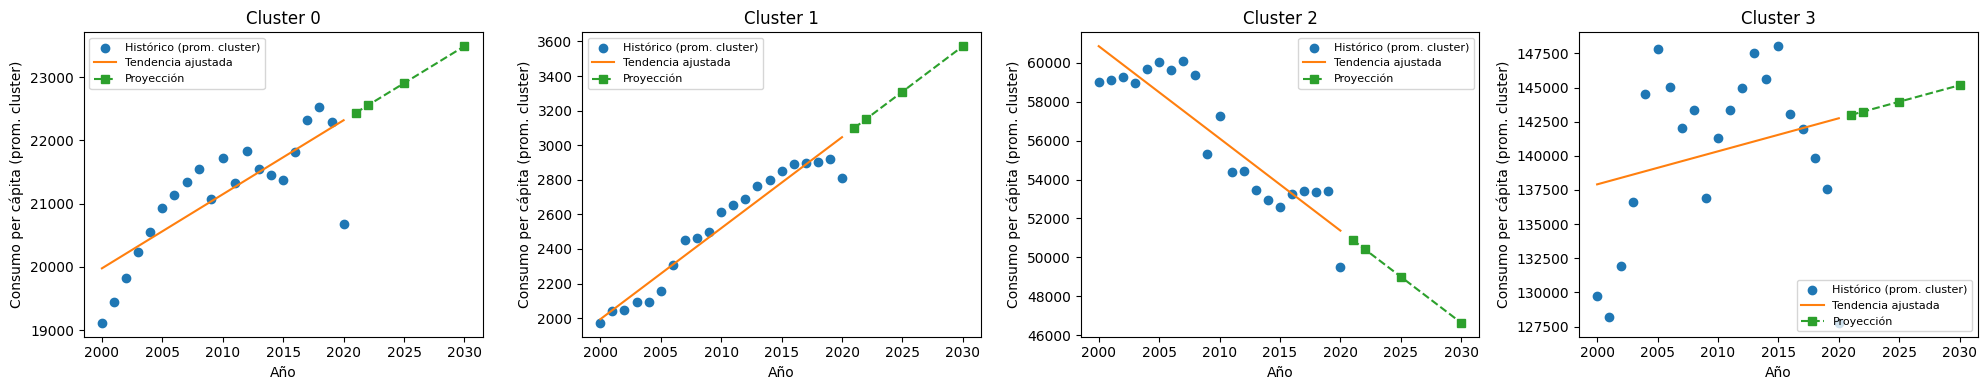

,cluster,Year,pred_Primary energy consumption per capita (kWh/person)
0,0,2021,22435.454853
1,0,2022,22552.532764
2,0,2025,22903.766496
3,0,2030,23489.156051
4,1,2021,3098.921940
5,1,2022,3151.537162
6,1,2025,3309.382827
7,1,2030,3572.458935
8,2,2021,50900.365536
9,2,2022,50425.848321


In [119]:
#Sacamos los promedios de consumo per cápita por cluster
target = "Primary energy consumption per capita (kWh/person)"

df_c = df.merge(country[["Entity", "cluster"]], on="Entity", how="inner")

ts = (
    df_c.groupby(["cluster", "Year"], as_index=False)[target]
    .mean()
    .sort_values(["cluster", "Year"])
)

future_years = np.array([2021, 2022, 2025, 2030])

fig, axes = plt.subplots(1, ts["cluster"].nunique(), figsize=(5 * ts["cluster"].nunique(), 4), squeeze=False)
axes = axes.ravel()

for i, cl in enumerate(sorted(ts["cluster"].unique())):
    sub = ts.loc[ts["cluster"] == cl, ["Year", target]]
    X = sub["Year"].values.reshape(-1, 1)
    y = sub[target].values

    model = LinearRegression()
    model.fit(X, y)

    X_future = future_years.reshape(-1, 1)
    y_future = model.predict(X_future)

    ax = axes[i]
    ax.scatter(X, y, label="Histórico (prom. cluster)")
    ax.plot(X, model.predict(X), color="C1", label="Tendencia ajustada")
    ax.plot(X_future, y_future, "s--", color="C2", label="Proyección")
    ax.set_title(f"Cluster {cl}")
    ax.set_xlabel("Año")
    ax.set_ylabel("Consumo per cápita (prom. cluster)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Tabla con proyecciones
rows = []
for cl in sorted(ts["cluster"].unique()):
    sub = ts.loc[ts["cluster"] == cl, ["Year", target]]
    X = sub["Year"].values.reshape(-1, 1)
    y = sub[target].values
    lr = LinearRegression().fit(X, y)
    for yr in future_years:
        rows.append({"cluster": cl, "Year": yr, f"pred_{target}": lr.predict([[yr]])[0]})

proyecciones = pd.DataFrame(rows)
proyecciones

Por cuestiones de tiempo, no fue posible desarrollar mejores conclusiones y modelos de regresión más detallados. Pero a modo preliminar, puede decirse que la HIPÓTESIS 0 podría confirmarse.